<a href="https://colab.research.google.com/github/younamminwhee/yolo3/blob/younamminwhee-patch-1/JBotDistance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
%pwd

'/content'

In [6]:
!git clone https://github.com/ultralytics/yolov5.git

Cloning into 'yolov5'...
remote: Enumerating objects: 17516, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 17516 (delta 6), reused 0 (delta 0), pack-reused 17497 (from 4)
Receiving objects: 100% (17516/17516), 16.62 MiB | 22.40 MiB/s, done.
Resolving deltas: 100% (12001/12001), done.


In [7]:
%cd yolov5
!pip install -r requirements.txt

/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
 

In [8]:
#사전 학습된 파라미터를 다운로드
!wget https://github.com/ultralytics/yolov5/releases/download/v7.0/yolov5s.pt

--2025-07-15 10:03:45--  https://github.com/ultralytics/yolov5/releases/download/v7.0/yolov5s.pt
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/264818686/381bd8a8-8910-4e9e-b0dd-2752951ef78c?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-07-15T10%3A48%3A44Z&rscd=attachment%3B+filename%3Dyolov5s.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-07-15T09%3A47%3A54Z&ske=2025-07-15T10%3A48%3A44Z&sks=b&skv=2018-11-09&sig=2Vbl2P9kgiPJubFVBQzy8%2BBQdQH6QDMKBFfQz3FbZBg%3D&jwt=eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc1MjU3NDEyNSwibmJmIjoxNzUyNTczODI1LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmUud

In [10]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import io
from PIL import Image
from ultralytics import YOLO
from google.colab import files
uploaded = files.upload()

Saving 스크린샷 2025-07-13 122421.png to 스크린샷 2025-07-13 122421.png


In [23]:
#Image 임포트 및 버전
from IPython.display import Image, clear_output
print({torch.__version__})

{'2.6.0+cu124'}


In [14]:
%pwd

'/content/yolov5'

# 추론

Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-7-15 Python-3.11.13 torch-2.6.0+cu124 CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


감지된 객체: person
거리 측정값: 7.4 m

감지된 객체: person
거리 측정값: 8.0 m

감지된 객체: person
거리 측정값: 7.7 m

감지된 객체: bottle


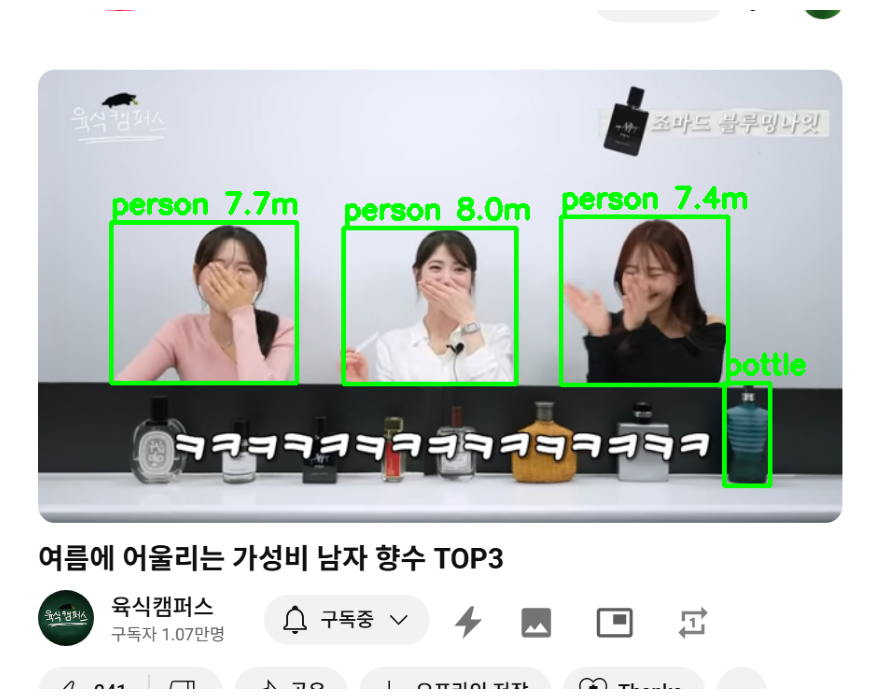

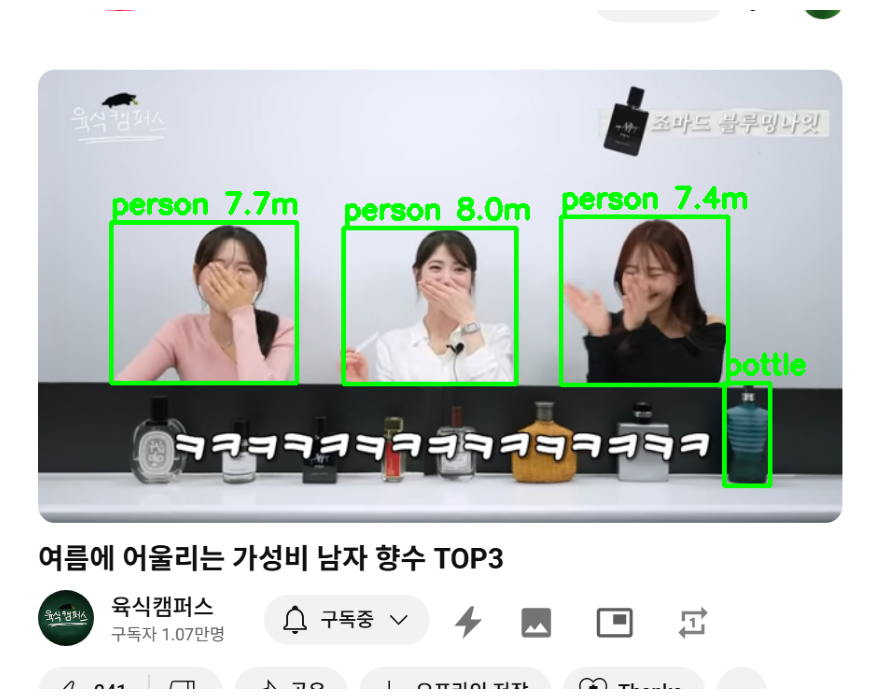

In [29]:
#출처 : 남효은님께 감사인사를 드립니다.
%matplotlib inline

import matplotlib.pyplot as plt

img = cv2.imread('스크린샷 2025-07-13 122421.png')  # BGR
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # 모델용 Blue Green RED 를 RGB포맷으로
img_bgr = img.copy()  # 시각화용 (BGR)

# 모델 로드
model = torch.hub.load('ultralytics/yolov5', 'yolov5s')

# 추론
results = model(img_rgb)

# 거리 계산용 높이
known_heights = {
    "cup": 10,
    "mouse": 11,
    "scissors": 19,
    "person": 166,
    "car": 150,
    "truck": 200,
    "bicycle": 110
}
focal_length_px = 800 #픽셀을 계산.기준

def estimate_distance(known_height_cm, focal_length_px, bbox_height_px):#노운하이트센치미터라는 알려진 위에 적은 것들, 카메라 초점 거리 , 바인딩박스의 높이 픽셀 간의 관계식은?
    return (known_height_cm * focal_length_px) / bbox_height_px

# 결과 반복
for *box, conf, cls in results.xyxy[0]:
    label = model.names[int(cls)].lower()
    print("감지된 객체:", label)

    x1, y1, x2, y2 = map(int, box)

    if label in known_heights:
        bbox_height = y2 - y1
        distance = estimate_distance(known_heights[label], focal_length_px, bbox_height)
        text = f"{label} {distance/100:.1f}m"
        print(f"거리 측정값: {distance / 100:.1f} m\n")
    else:
        text = label

    cv2.rectangle(img_bgr, (x1, y1), (x2, y2), (0, 255, 0), 4)
    cv2.putText(img_bgr, text, (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 3)

# 출력용 RGB 변환
img_show = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 출력
plt.figure(figsize=(11, 9))
plt.imshow(img_show)
plt.axis("off")
plt.show()

In [ ]:
'''참고 사이트:
https://yobbicorgi.tistory.com/2
https://yobbicorgi.tistory.com/34
https://yobbicorgi.tistory.com/39
https://diary0198.tistory.com/7
'''